If you want this to be *substantial*, the trick is to stop treating it like “NLP on political text” and start treating it like **a reproducible measurement framework for rhetoric**. Then the “new insights” are: what you can quantify, how stable it is, and what changes across years.

Your three transcripts are a clean corpus (same genre, same setting, different era): Obama 2012 ([millercenter.org][1]), Trump 2020 ([millercenter.org][2]), Biden 2024 ([millercenter.org][3]).

## A story that sounds like insight (and is)

### Thesis

**LLMs are not just for summarizing speeches. They let you instrument speeches.**
You can quantify: agenda structure, framing, coalition targeting, and rhetorical “moves,” then compare across years.

### The punchier version

* Word clouds show **frequency**.
* Transformers let you measure **salience, structure, and framing**.

## The 5 analysis lenses that make a real “speech analytics” narrative

### 1) Agenda structure: what buckets exist and how the speech allocates time

Deliverable:

* Chunk speech into fixed units (say 3–5 sentences).
* Embed each chunk.
* Cluster chunks into topics (k ~ 8–12).
* Output: topic labels + % of speech per topic + a timeline strip showing topic order.

Insight you can credibly claim:

* SOTUs have a predictable scaffold, but **the allocation and sequencing** differ, and the differences are measurable.

Why it’s good:

* It’s visual and robust. It still works if the model is small.

### 2) Rhetorical moves: “what is the speaker doing right now?”

Instead of topics, label each chunk as a *move*, like:

* accomplishment/scoreboard
* threat/urgency
* values/identity
* policy proposal
* bipartisanship appeal
* contrast/adversary framing
* anecdote/human story
* call to action

How:

* Use an open-source LLM to classify each chunk into one move (or multi-label).
* Then compare move distributions across years.

Insight:

* You can show, for example, one speech spending more time on “scoreboard + contrast,” another on “threat + values + call to action,” etc., without doing punditry.

### 3) Framing ratios: policy vs values vs conflict

A simple, high-signal metric set:

* **Policy density**: how often we see concrete proposals, numbers, legislation names.
* **Values density**: words/phrases tied to freedom, democracy, fairness, dignity, etc.
* **Conflict density**: explicit “they/our opponents,” blame, attack, “the other side,” “predecessor,” etc.

Why it’s real:

* This is the “instrumentation” angle. You’re quantifying how a speech persuades, not just what it says.

You already see distinct openings in 2020 and 2024 that are basically “scoreboard” vs “urgent threat framing” right out of the gate. ([Miller Center][2])

### 4) Coalition targeting: “who is being addressed?”

Extract and categorize mentions of:

* workers, families, seniors
* small business
* military/veterans
* women
* immigrants/border/security
* students/education
* rural/farmers/manufacturing
* allies/adversaries

How:

* NER + noun phrase extraction + a lightweight classifier (or rules).
* Output: a “who is the audience” scoreboard by year.

Insight:

* Reelection-year speeches are coalition maintenance. This lets you show it with data.

### 5) Entity + policy network: what concepts are linked together

Deliverable:

* Build a graph where nodes are entities/policies and edges are co-occurrence within a sentence/window.
* Community detection reveals “issue constellations.”

Insight:

* This is where you get non-obvious findings like: “In 2024, democracy framing is tightly linked to foreign policy references early,” which is visible in the transcript opening. ([Miller Center][3])

## “New insights” you can safely aim for (without guessing results)

These are phrased as research questions you can answer with the pipeline:

1. **How stable is the SOTU template?**
   Do all three show similar topic ordering (foreign policy opener, economic core, domestic policy laundry list, closing values), or does one break the mold?

2. **Which speech is more “proposal-heavy” vs “frame-heavy”?**
   Quantify policy density and values density per 1,000 words.

3. **Is the “adversary” mostly external or internal?**
   2024 explicitly frames threats at home and abroad in the opening. ([Miller Center][3])
   2020’s early framing is accomplishment + national resurgence language. ([Miller Center][2])
   Obama 2012 opens with military accomplishments and then moves into “economy built to last.” ([Miller Center][1])

4. **Do rhetorical moves cluster by era?**
   2012: blueprint language, “built to last” economic narrative appears early. ([Miller Center][1])
   2020: “great American comeback” scoreboard framing is explicit. ([Miller Center][2])
   2024: democracy under assault framing is explicit. ([Miller Center][3])

That’s not punditry. That’s the speeches telling you what they’re doing.

## What makes this “LLM-powered” and not “statistics in a trench coat”

Be explicit in the write-up:

* **Embeddings** give you semantic grouping (topics, structure).
* **LLM classification** gives you rhetorical move labeling at scale.
* Optional: attention-based salience as a “lens,” but don’t hang the paper on attention. It’s a demo tool more than an evidence tool.

## A clean “mini paper” outline you can publish (blog/LinkedIn)

1. Problem: Comparing speeches is usually vibes.
2. Data: 2012, 2020, 2024 SOTU transcripts (Miller Center).
3. Method: chunking, embeddings + clustering, move labeling, density metrics, entity graph.
4. Findings: 3–6 charts with short interpretations.
5. Limitations: model bias, transcript formatting, classification uncertainty, sensitivity to chunk size/k.
6. Repro: a single notebook + config file + pinned model versions.

## If you want one chart that wins hearts immediately

Do the **timeline strip**: x-axis = chunk index; color = topic cluster; annotate 5–8 topic labels. It makes “structure” visible in 2 seconds.

---

If you want, I can give you a tight “analysis spec” (inputs/outputs, parameter defaults, and exactly which models to use locally) so you can run it once and write about the results without fiddling live.

[1]: https://millercenter.org/the-presidency/presidential-speeches/january-24-2012-2012-state-union-address "January 24, 2012: 2012 State of the Union Address | Miller Center"
[2]: https://millercenter.org/the-presidency/presidential-speeches/february-4-2020-state-union-address "February 4, 2020: State of the Union Address | Miller Center"
[3]: https://millercenter.org/the-presidency/presidential-speeches/march-7-2024-state-union-address "March 7, 2024: State of Union Address | Miller Center"


Yes. The spec is your guardrails. It forces you to decide what you will measure, how you will measure it, and what artifacts you will produce, before you get distracted by shiny model knobs.

Here is a practical analysis spec you can use as the backbone for a substantial demo and a write-up.

## Speech Analytics Spec v1

### 0) Goal

Compare 2012, 2020, 2024 SOTU speeches on:

* agenda structure (topics over time)
* rhetorical moves (what the speaker is doing)
* framing densities (policy vs values vs conflict)
* coalition targeting (who is addressed)
* entity-policy networks (what concepts are linked)

### 1) Data

Source transcripts (canonical):

* 2012 SOTU (Miller Center)
* 2020 SOTU (Miller Center)
* 2024 SOTU (Miller Center)

Ingestion rules:

* Strip navigation, headers, footers.
* Keep only transcript body.
* Normalize whitespace.
* Preserve paragraph boundaries if possible.

Output artifacts:

* `data/raw/{year}.txt`
* `data/clean/{year}.json` with fields:

  * `year`
  * `source_url`
  * `paragraphs[]` (cleaned strings)

### 2) Chunking

Purpose: create comparable units for embedding and labeling.

Rules:

* Split into sentences.
* Group into chunks of 3 sentences (default).
* Overlap: 1 sentence overlap (default) to smooth boundaries.

Parameters:

* `chunk_sentences = 3`
* `chunk_overlap = 1`
* `max_tokens_per_chunk = 180` (truncate or re-chunk if needed)

Output:

* `chunks/{year}.jsonl` with:

  * `chunk_id`
  * `year`
  * `chunk_index`
  * `text`
  * `char_start`, `char_end` (optional)

### 3) Topic structure (embeddings + clustering)

Model:

* Sentence embeddings: `sentence-transformers/all-MiniLM-L6-v2` (fast, solid)

Method:

* Embed each chunk.
* Cluster within each speech OR across all speeches (choose one; default is across all to keep topic IDs consistent).
* Clustering algorithm: `MiniBatchKMeans`

Defaults:

* `k_topics = 10`
* `cluster_scope = "global"` (all years together)
* `random_state = 0`

Topic labeling:

* For each topic cluster, extract top n-grams (1–2 grams) by count within that cluster.
* Optionally use KeyBERT-style centroid similarity for nicer labels.

Outputs:

* `topics/global_topics.json`:

  * `topic_id -> label_terms[]`
* `topics/chunk_topics.jsonl`:

  * `chunk_id -> topic_id`

Primary visuals:

* Topic timeline strip per speech (chunk index vs topic color)
* Topic share bar chart per speech (% chunks per topic)

### 4) Rhetorical move labeling

Goal: classify each chunk into one rhetorical move.

Moves (fixed label set):

1. Accomplishment/scoreboard
2. Problem/threat/urgency
3. Values/identity
4. Policy proposal
5. Bipartisanship/invitation
6. Contrast/adversary framing
7. Anecdote/human story
8. Call to action / closing

Method options:
A) Local LLM classifier (preferred if you want “LLM-powered”)

* Use a small instruction model you can run locally (examples: Llama 3.1 8B Instruct, Qwen2.5 7B Instruct) via Transformers or Ollama.
* Prompt: single-label classification with a short rationale.
* Use temperature 0 for stability.

B) Non-LLM baseline (backup)

* Use a linear classifier on embeddings with a small hand-labeled set (30–60 chunks). This is more work up front, more defensible long term.

Outputs:

* `moves/chunk_moves.jsonl`:

  * `chunk_id -> move_label`
  * optional `rationale` (keep short)

Visuals:

* Move timeline strip per speech
* Move distribution per year

Reliability check:

* Label 30 random chunks twice (same model, same prompt) and confirm stability at temp=0.
* Optionally have a human label 20 chunks and compute agreement.

### 5) Framing densities

Compute per speech and per chunk:

* Policy density: presence of numbers, bill names, program names, “will/plan/act,” etc.
* Values density: curated lexicon (freedom, democracy, dignity, justice, rights, etc.)
* Conflict density: “they/them,” blame verbs, opponent references, “predecessor,” “extremists,” etc.

This is mostly rules + lexicons. Keep it transparent.

Outputs:

* `metrics/chunk_densities.jsonl`
* `metrics/speech_summary.json`

Visuals:

* Line plot of densities across chunk index
* Summary table per year (per 1k words)

### 6) Coalition targeting

Extract mentions of audience groups:

* workers, families, seniors, veterans, small business, women, students, immigrants, etc.

Method:

* Noun phrase extraction + dictionary mapping (simple and robust)
* Optionally refine with an LLM: “Does this sentence target any of these groups?”

Outputs:

* `coalition/mentions.jsonl` with normalized categories
* per-speech counts and rates

Visual:

* Radar chart or grouped bars per year

### 7) Entity-policy network

Entities:

* NER (spaCy) for PERSON/ORG/GPE plus key noun phrases.

Edges:

* Co-occurrence within a sentence or within a 2-sentence window.
* Weight edges by frequency.

Outputs:

* `graph/{year}_nodes.csv`, `graph/{year}_edges.csv`

Visual:

* Network plot (or export to Gephi)

### 8) Deliverables checklist (what you ship)

Minimum viable “substantial” package:

* One notebook that runs end-to-end
* 5 figures:

  1. topic timeline (x3 speeches)
  2. topic share comparison
  3. move distribution comparison
  4. density lines comparison
  5. coalition targeting comparison
* A short write-up: “method, findings, limitations”

### 9) Guardrails (so you do not oversell)

* Do not claim “intent” or “truth,” only measured patterns.
* Report sensitivity: show results with k=8 and k=12 and confirm the main story survives.
* Keep model versions pinned.

---

How you use this in practice:

* You build the demo by implementing the spec top to bottom.
* Each section produces a tangible artifact.
* If something breaks, you know exactly which stage failed.

If you want, I can turn this into a repo skeleton (folders + config YAML + notebook outline) and a short “demo talk track” that explains each chart in one sentence.


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics")

PATH_TOPICS = BASE / "data/derived/topics_global/global_chunk_topics.jsonl"
PATH_TOPIC_LABELS = BASE / "data/derived/topics_global/global_topic_labels_llm.json"
PATH_RHET = BASE / "data/derived/rhetoric/global_chunk_rhetoric.jsonl"

def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

topics = pd.DataFrame(read_jsonl(PATH_TOPICS))
rhet = pd.DataFrame(read_jsonl(PATH_RHET))


# Treat empty strings as NaN
rhet["error"] = rhet["error"].replace("", np.nan)

# Define "good" rows
rhet["is_good"] = rhet["tone"].notna() & rhet["device"].notna() & rhet["target"].notna() & rhet["error"].isna()

# Confidence ranking
conf_rank = {"low": 0, "med": 1, "high": 2}
rhet["conf_rank"] = rhet["confidence"].map(conf_rank).fillna(-1)

# Sort so best rows come first, then drop duplicates on chunk_id
rhet_sorted = rhet.sort_values(
    by=["is_good", "conf_rank"],
    ascending=[False, False],
)

rhet_dedup = rhet_sorted.drop_duplicates(subset=["chunk_id"], keep="first").drop(columns=["is_good", "conf_rank"])

# Now merge using the deduped rhetoric
df = topics.merge(
    rhet_dedup,
    on=["chunk_id"],  # chunk_id is unique; year/index/topic are already in topics
    how="left",
    suffixes=("", "_r")
)



In [2]:
import json
from pathlib import Path
import pandas as pd

BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics")

# Load global topic labels (LLM)
PATH_TOPIC_LABELS = BASE / "data/derived/topics_global/global_topic_labels_llm.json"
topic_labels_raw = json.loads(PATH_TOPIC_LABELS.read_text(encoding="utf-8"))

topic_label_map = {}
for k, v in topic_labels_raw.items():
    try:
        tid = int(k)
    except Exception:
        tid = int(v.get("topic_id", k))
    # v might be a dict with "label"
    topic_label_map[tid] = (v.get("label") if isinstance(v, dict) else str(v)).title()

# Canonicalize df fields: keep left-side (topics) values
df = df.copy()
df["topic_label"] = df["topic_id"].map(topic_label_map)

# Drop the redundant rhs cols
df = df.drop(columns=["year_r", "chunk_index_r", "topic_id_r", "uses_guest_example_r", "guest_count_r"])

print("Rows:", len(df))
print("Missing rhetoric labels:", df["tone"].isna().sum())
df.head(3)


Rows: 2027
Missing rhetoric labels: 51


,year,chunk_id,chunk_index,uses_guest_example,guest_count,topic_id,tone,device,target,confidence,evidence,model,n_clauses,device_mix,tone_mix,error,topic_label
0,2010,2010_0000,0,False,0,6,unifying,values,the_public,high,{'device': 'Our Constitution declares that fro...,mistral:latest,1,{'values': 1},{'unifying': 1},NaN,Military Service: Ceremonial Events
1,2010,2010_0001,1,False,0,22,grave,values,the_public,high,{'device': 'assume that our progress was inevi...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Progress
2,2010,2010_0002,2,False,0,22,grave,values,the_public,high,{'device': 'These were the times that tested t...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Progress


In [3]:
missing = df[df["tone"].isna()][["year","chunk_id","chunk_index","topic_id","topic_label"]].copy()
missing.shape, missing.head()


((51, 5),
      year   chunk_id  chunk_index  topic_id                     topic_label
 71   2010  2010_0071           71         2     Financial Market Regulation
 89   2010  2010_0089           89        17  Higher Education Affordability
 99   2010  2010_0099           99        21              Health Care Reform
 322  2012  2012_0110          110         8                    Clean Energy
 326  2012  2012_0114          114         8                    Clean Energy)

In [4]:
ALLOWED_DEVICES = {"policy_ask","credit_claim","attack","exemplar","values","threat"}
ALLOWED_TONES = {"neutral","unifying","adversarial","upbeat","grave","urgent"}
ALLOWED_TARGETS = {"the_public","institution","special_guests","domestic_opponents","foreign_adversaries","allies","unspecified"}

def validate_pred(p):
    if not p: 
        return None
    d = p.get("device")
    t = p.get("tone")
    g = p.get("target")
    if d not in ALLOWED_DEVICES: 
        return None
    if t not in ALLOWED_TONES:
        return None
    if g not in ALLOWED_TARGETS:
        return None
    return p


In [5]:
from sotu_analytics.prompts import build_rhetoric_prompt
from sotu_analytics.models.topic_label_llm import ollama_generate_json

# Load chunk text index
def read_jsonl(path: Path):
    out = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            out.append(json.loads(line))
    return out

def safe_ollama_json(model, prompt, timeout=180, num_predict=160, retries=1):
    last_err = None
    for _ in range(retries + 1):
        try:
            return ollama_generate_json(model, prompt, temperature=0.0, timeout=timeout, num_predict=num_predict)
        except (json.JSONDecodeError, ValueError) as e:
            last_err = e
            prompt = prompt + "\n\nREMINDER: Return ONE JSON object only. No double quotes inside evidence strings.\n"
    return {}


chunk_text = {}
for y in sorted(df["year"].unique()):
    rows = read_jsonl(BASE / f"data/chunks/{y}.jsonl")
    for r in rows:
        chunk_text[r["chunk_id"]] = r["text"]

patch_rows = []
model = "qwen2.5:14b-instruct-q4_K_M"

for _, row in missing.iterrows():
    year = int(row["year"])
    cid = row["chunk_id"]
    prompt = build_rhetoric_prompt(year, chunk_text[cid])
    resp = validate_pred(safe_ollama_json(model, prompt, timeout=180, num_predict=160, retries=1))
    if resp:
        patch_rows.append({
            "year": year,
            "chunk_id": cid,
            "tone": resp.get("tone"),
            "device": resp.get("device"),
            "target": resp.get("target"),
            "uses_guest_example": resp.get("uses_guest_example"),
            "confidence": resp.get("confidence"),
            "evidence": resp.get("evidence", {}),
            "model": model,
        })

patch = pd.DataFrame(patch_rows)
patch.head(), patch["tone"].isna().sum()


(   year   chunk_id         tone      device       target  uses_guest_example  \
 0  2010  2010_0071        grave      threat   the_public               False   
 1  2010  2010_0089       upbeat  policy_ask   the_public               False   
 2  2010  2010_0099       upbeat  policy_ask   the_public               False   
 3  2012  2012_0110  adversarial  policy_ask  institution               False   
 4  2012  2012_0114       upbeat  policy_ask  institution               False   
 
   confidence                                           evidence  \
 0       high  {'device': 'We need to make sure consumers and...   
 1       high  {'device': 'I urge the Senate to follow the Ho...   
 2       high  {'device': 'give small businesses and uninsure...   
 3       high  {'device': 'Congress shouldn’t at least set a ...   
 4       high  {'device': 'Send me a bill that creates these ...   
 
                          model  
 0  qwen2.5:14b-instruct-q4_K_M  
 1  qwen2.5:14b-instruct-q4_K_M  


In [6]:
df2 = df.merge(patch, on=["year","chunk_id"], how="left", suffixes=("", "_patch"))

for col in ["tone","device","target","uses_guest_example","confidence","evidence","model"]:
    df2[col] = df2[col].fillna(df2[f"{col}_patch"])

df2 = df2.drop(columns=[c for c in df2.columns if c.endswith("_patch")])

print("Missing after patch:", df2["tone"].isna().sum())


Missing after patch: 3


In [7]:
import json
from pathlib import Path

BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics/data/derived/topics_global")

macro_map_path = BASE / "global_topic_macro_map.json"
macro_raw = json.loads(macro_map_path.read_text(encoding="utf-8"))

macro_topic_map = {int(k): v.get("macro_topic") for k, v in macro_raw.items()}
subtopic_map = {int(k): v.get("subtopic") for k, v in macro_raw.items()}
macro_conf_map = {int(k): v.get("confidence") for k, v in macro_raw.items()}

df2["macro_topic"] = df2["topic_id"].map(macro_topic_map)
df2["subtopic"] = df2["topic_id"].map(subtopic_map)
df2["macro_confidence"] = df2["topic_id"].map(macro_conf_map)

print("Missing macro_topic:", df2["macro_topic"].isna().sum())
#df2[["year","topic_id","topic_label","macro_topic","subtopic","macro_confidence","tone","device"]].head(10)
df2.groupby(by=["macro_topic","topic_label","subtopic"]).count()[['year']].reset_index().sort_values(by=["macro_topic","year"], ascending=[True, False])


Missing macro_topic: 0


,macro_topic,topic_label,subtopic,year
0,Economy and Jobs,Economic Inequality,Economic Inequality,113
2,Economy and Jobs,Job Creation,Job Creation,98
1,Economy and Jobs,Financial Market Regulation,Financial Market Regulation,61
4,Education and Workforce,Job Training,Job Training,71
3,Education and Workforce,Higher Education Affordability,Higher Education Affordability,68
5,Foreign Policy and Alliances,Global Security,Global Security,90
6,Foreign Policy and Alliances,Ukraine Support,Ukraine Support,48
7,Governance and Institutions,Government Functionality,Government Functionality,97
8,Healthcare,Health Care Reform,Affordable Care Act,64
11,Healthcare,Women'S Health,Women's Health,56


In [8]:
df2.groupby(by=["macro_topic"]).count()[['year']].reset_index().sort_values(by="year", ascending=False).rename(columns={"year": "count"})

,macro_topic,count
9,National Security and Military,386
0,Economy and Jobs,272
8,National Identity and Values,265
4,Healthcare,220
11,"Taxes, Budget, and Debt",211
1,Education and Workforce,139
2,Foreign Policy and Alliances,138
3,Governance and Institutions,97
6,"Industry, Technology, and Trade",87
10,Rights and Social Issues,77


In [26]:
import json
import pandas as pd
from pathlib import Path
pd.options.display.max_colwidth = 750
BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics")

# df should already contain chunk_id + subtopic
target_subtopic = "Fundamental Rights"

hits = df2[df2["subtopic"].fillna("").str.lower().eq(target_subtopic.lower())].copy()
print("Rows:", len(hits), "Years:", sorted(hits["year"].unique()))

# Load chunk text for only the years we need
chunk_text_by_id = {}
for y in sorted(hits["year"].unique()):
    p = BASE / "data" / "chunks" / f"{int(y)}.jsonl"
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            chunk_text_by_id[obj["chunk_id"]] = obj.get("text", "")

hits["text"] = hits["chunk_id"].map(chunk_text_by_id)

# Inspect: sorted by year, then chunk_index
cols = ["year","chunk_id","chunk_index","macro_topic","subtopic","topic_label","tone","device","target","text"]
cols = ["year","chunk_id","topic_id", "macro_topic","subtopic","tone","device","text"]
hits.sort_values(["year","chunk_index"])[cols].head(30)


Rows: 77 Years: [np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2026)]


,year,chunk_id,topic_id,macro_topic,subtopic,tone,device,text
162,2010,2010_0162,10,Rights and Social Issues,Fundamental Rights,unifying,values,All of us are committed to its defense. So let's put aside the schoolyard taunts about who's tough. Let's reject the false choice between protecting our people and upholding our values.
163,2010,2010_0163,10,Rights and Social Issues,Fundamental Rights,unifying,values,Let's reject the false choice between protecting our people and upholding our values. Let's leave behind the fear and division and do what it takes to defend our Nation and forge a more hopeful future for America and for the world. That's the work we began last year.
185,2010,2010_0185,10,Rights and Social Issues,Fundamental Rights,unifying,values,"We find unity in our incredible diversity, drawing on the promise enshrined in our Constitution: The notion that we're all created equal; that no matter who you are or what you look like, if you abide by the law, you should be protected by it; if you adhere to our common values, you should be treated no different than anyone else. We must continually renew this promise. My administration has a Civil Rights Division that is once again prosecuting civil rights violations and employment discrimination."
186,2010,2010_0186,10,Rights and Social Issues,Fundamental Rights,unifying,credit_claim,"My administration has a Civil Rights Division that is once again prosecuting civil rights violations and employment discrimination. We finally strengthened our laws to protect against crimes driven by hate. This year, I will work with Congress and our military to finally repeal the law that denies gay Americans the right to serve the country they love because of who they are."
187,2010,2010_0187,10,Rights and Social Issues,Fundamental Rights,unifying,policy_ask,"This year, I will work with Congress and our military to finally repeal the law that denies gay Americans the right to serve the country they love because of who they are. It's the right thing to do. We're going to crackdown on violations of equal pay laws so that women get equal pay for an equal day's work."
344,2012,2012_0132,10,Rights and Social Issues,Fundamental Rights,unifying,values,"I will not back down from protecting our kids from mercury poisoning, or making sure that our food is safe and our water is clean. I will not go back to the days when health insurance companies had unchecked power to cancel your policy, deny your coverage, or charge women differently than men. And I will not go back to the days when Wall Street was allowed to play by its own set of rules."
395,2012,2012_0183,10,Rights and Social Issues,Fundamental Rights,unifying,values,"We will stand against violence and intimidation. We will stand for the rights and dignity of all human beings - men and women; Christians, Muslims and Jews. We will support policies that lead to strong and stable democracies and open markets, because tyranny is no match for liberty."
406,2012,2012_0194,10,Rights and Social Issues,Fundamental Rights,urgent,credit_claim,"To stay one step ahead of our adversaries, I’ve already sent this Congress legislation that will secure our country from the growing dangers of cyber-threats. Above all, our freedom endures because of the men and women in uniform who defend it. As they come home, we must serve them as well as they’ve served us."
540,2014,2014_0117,10,Rights and Social Issues,Fundamental Rights,adversarial,attack,But let’s not have another forty-something votes to repeal a law that’s already helping millions of Americans like Amanda. The first forty were plenty. We got it.
541,2014,2014_0118,10,Rights and Social Issues,Fundamental Rights,unifying,values,"We got it. We all owe it to the American people to say what we’re for, not just what we’re against. And if you want to know the real impact this law is having, just talk to Governor Steve Beshear of Kentucky, who’s here tonight."


In [9]:
def top_tone_topics(data, year: int, tone: str, top_n=8, min_chunks=10):
    sub = data[(data["year"] == year) & data["tone"].notna()].copy()
    grp = sub.groupby("topic_label")["tone"].agg(
        total="count",
        tone_count=lambda s: (s == tone).sum()
    )
    grp = grp[grp["total"] >= min_chunks].copy()
    grp["pct"] = (grp["tone_count"] / grp["total"] * 100).round(1)
    return grp.sort_values("pct", ascending=False).head(top_n)

for y in sorted(df2["year"].unique()):
    print(f"\n{y} - most adversarial topics")
    display(top_tone_topics(df2, y, "adversarial", top_n=10, min_chunks=10))
    print(f"\n{y} - most unifying topics")
    display(top_tone_topics(df2, y, "unifying", top_n=10, min_chunks=10))



2010 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Government Functionality,29,8,27.6
Fiscal Responsibility,32,2,6.2
Economic Inequality,12,0,0.0
Financial Market Regulation,15,0,0.0
Health Care Reform,15,0,0.0
Job Creation,12,0,0.0
National Progress,19,0,0.0
Tax Equity,10,0,0.0



2010 - most unifying topics


,total,tone_count,pct
topic_label,,,
National Progress,19,16,84.2
Job Creation,12,6,50.0
Government Functionality,29,12,41.4
Fiscal Responsibility,32,5,15.6
Financial Market Regulation,15,2,13.3
Health Care Reform,15,1,6.7
Economic Inequality,12,0,0.0
Tax Equity,10,0,0.0



2012 - most adversarial topics


...

,total,tone_count,pct
topic_label,,,
National Progress,26,18,69.2
Optimism And Resilience,19,8,42.1
Fundamental Rights,25,7,28.0
Job Training,15,4,26.7
Women'S Health,12,3,25.0
Economic Inequality,17,4,23.5
Government Functionality,17,4,23.5
Military Sacrifice,13,3,23.1
Fiscal Responsibility,15,3,20.0



2026 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Fiscal Responsibility,13,5,38.5
Financial Market Regulation,12,4,33.3
Border Security,24,7,29.2
Government Functionality,14,4,28.6
Women'S Health,17,4,23.5
Optimism And Resilience,41,8,19.5
Economic Inequality,24,2,8.3
Tax Equity,13,1,7.7
National Progress,21,1,4.8



2026 - most unifying topics


,total,tone_count,pct
topic_label,,,
National Progress,21,9,42.9
Military Service: Ceremonial Events,38,14,36.8
Women'S Health,17,5,29.4
Military Sacrifice,43,10,23.3
Tax Equity,13,2,15.4
Government Functionality,14,2,14.3
Military Service: Combat Injuries,37,5,13.5
Optimism And Resilience,41,4,9.8
Fiscal Responsibility,13,1,7.7


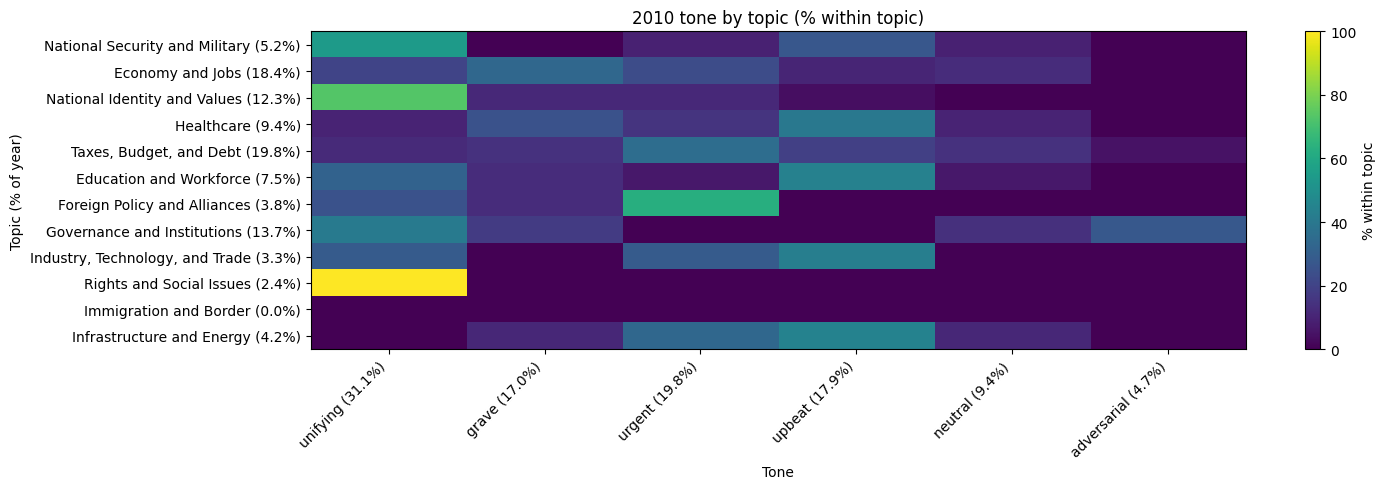

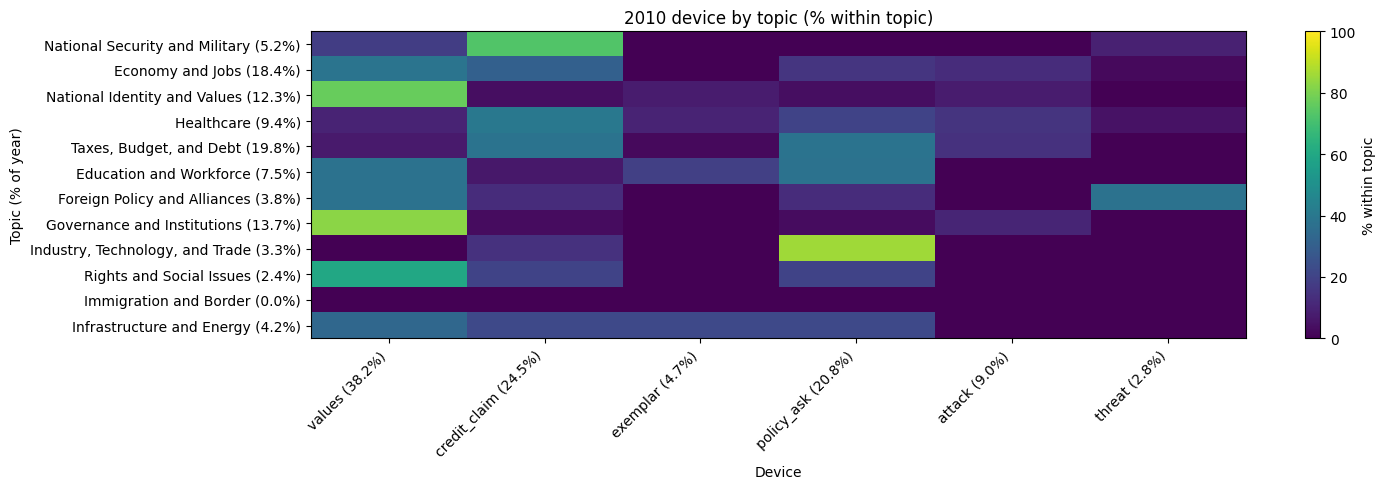

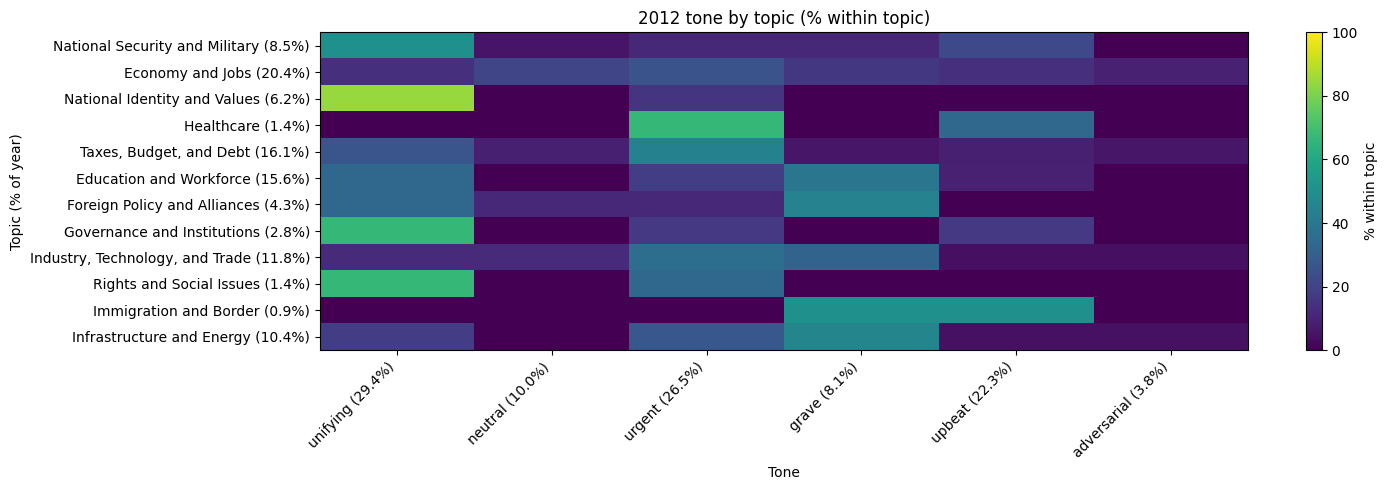

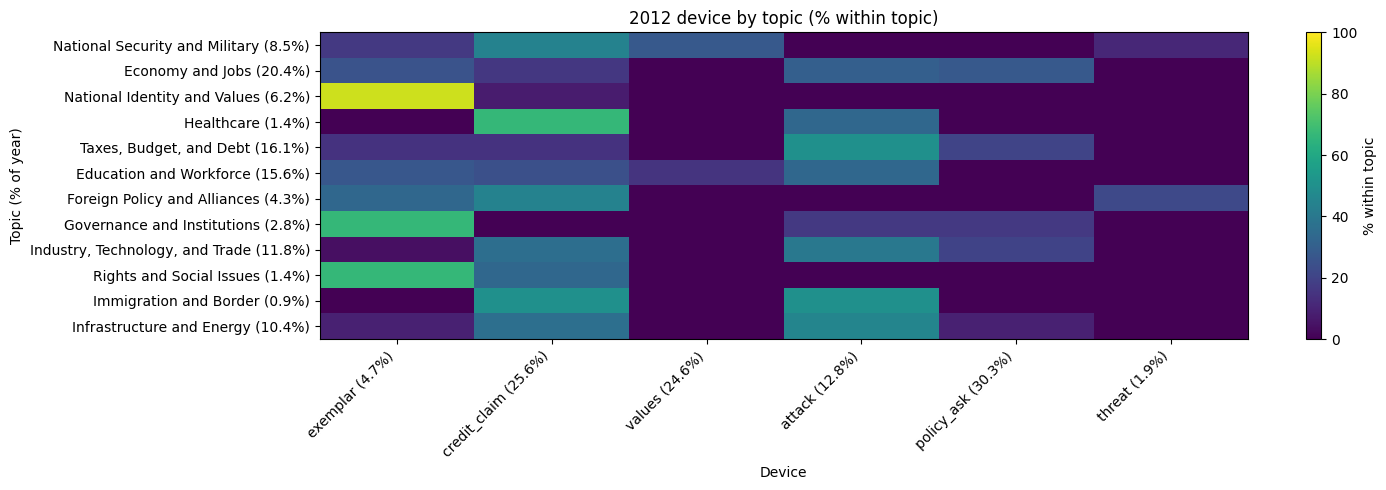

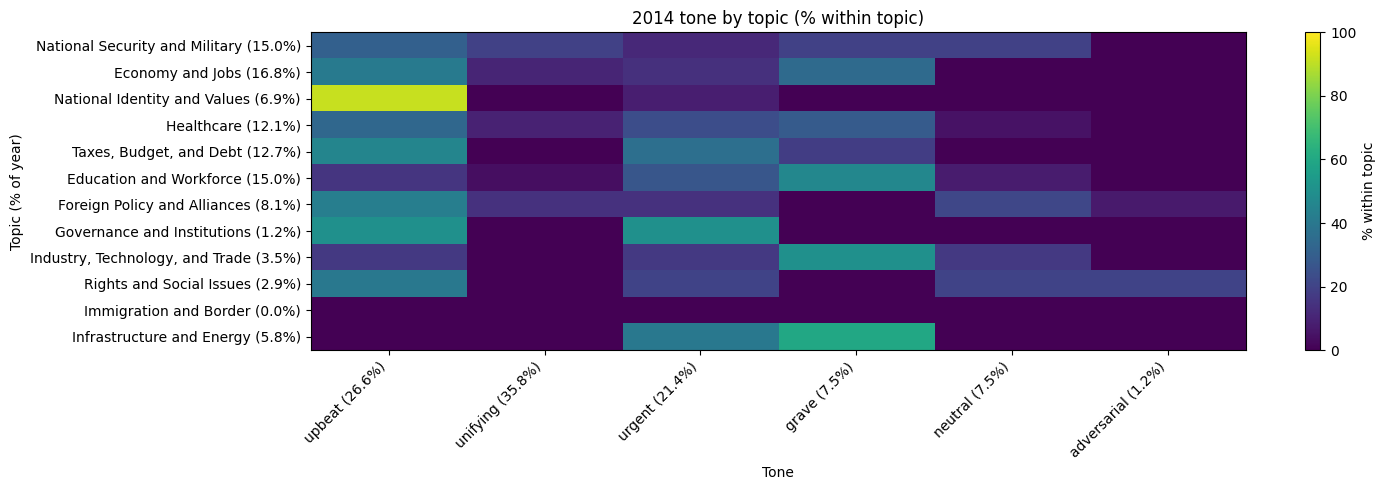

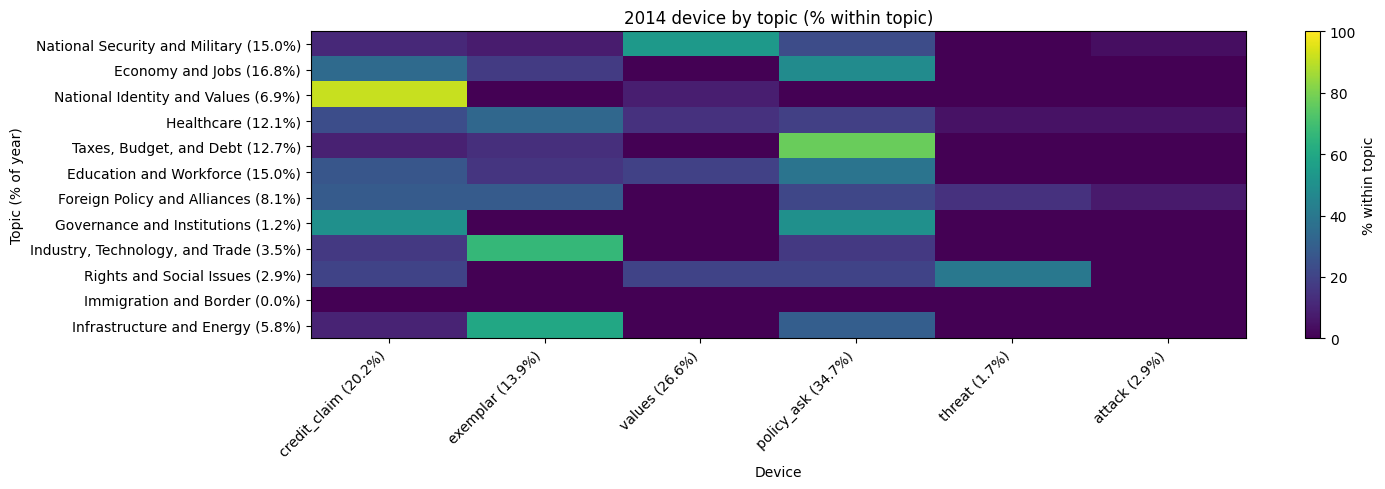

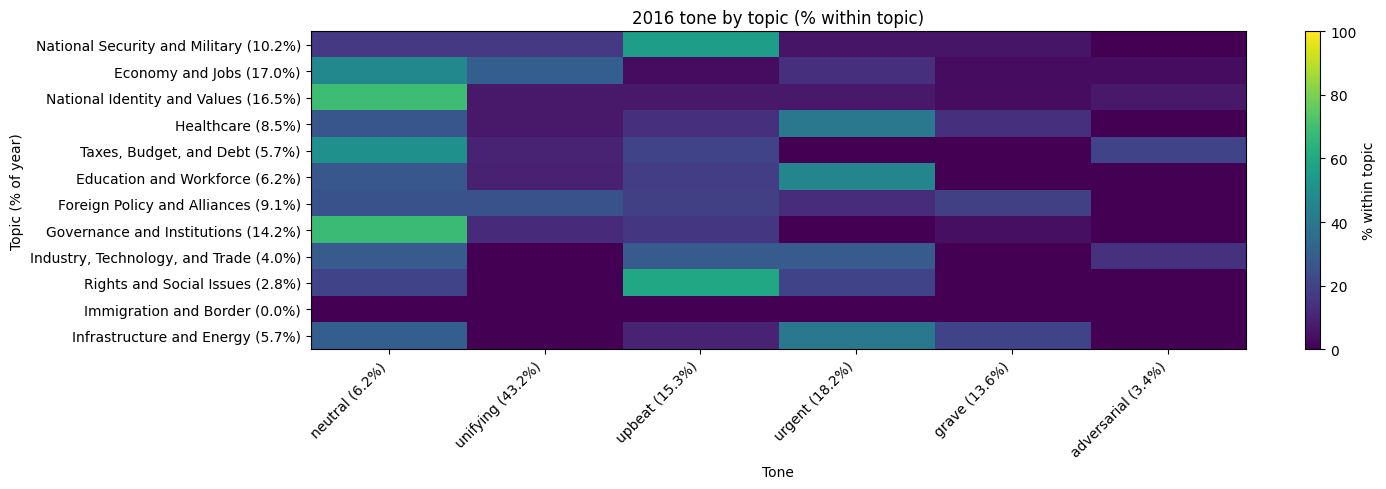

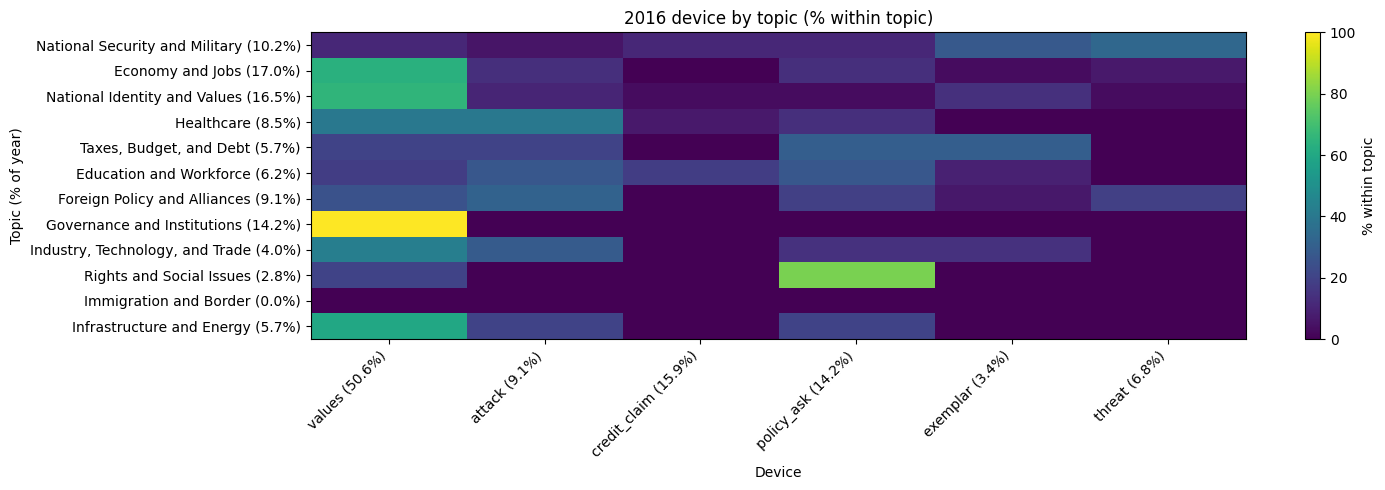

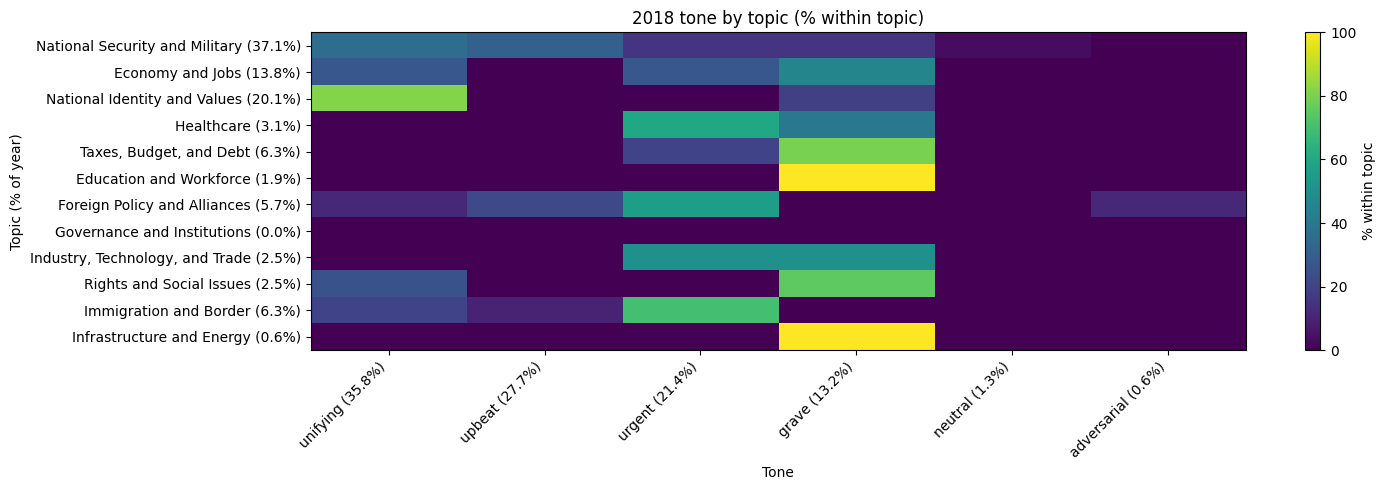

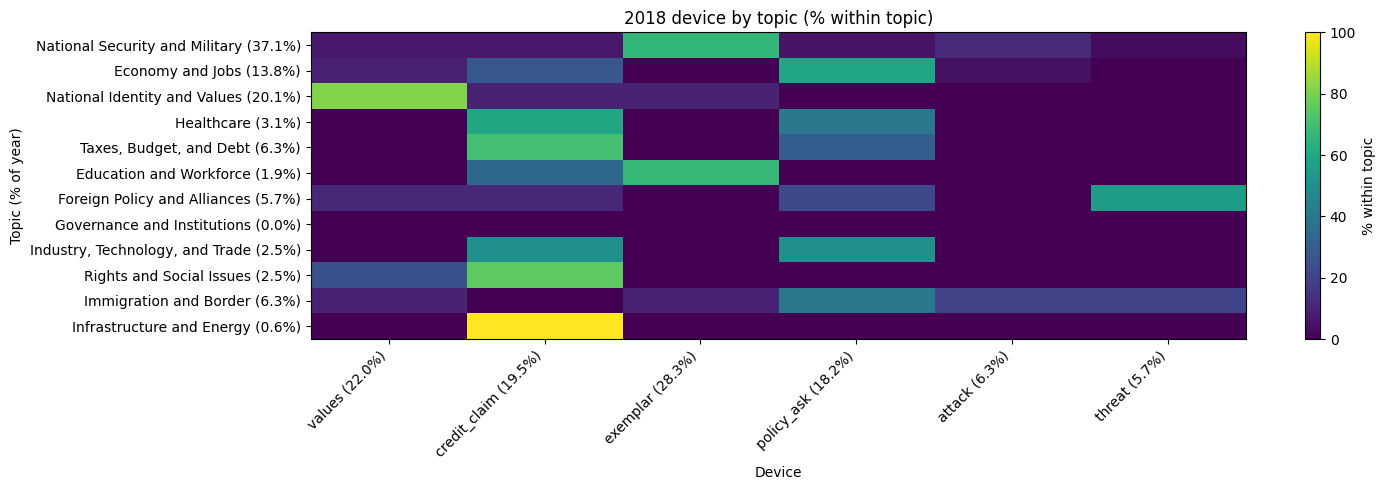

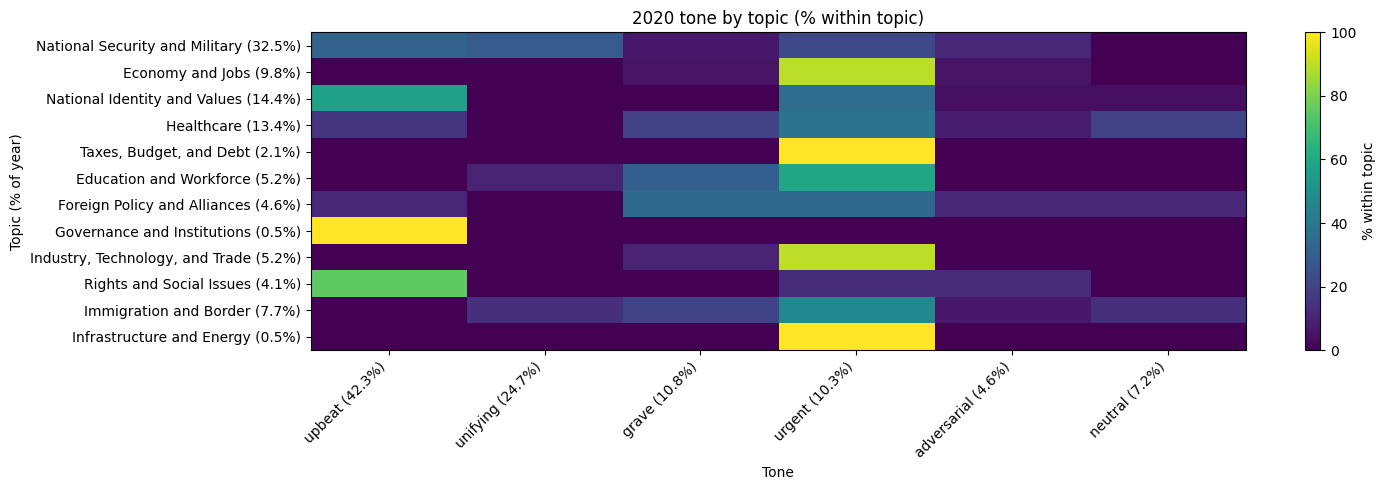

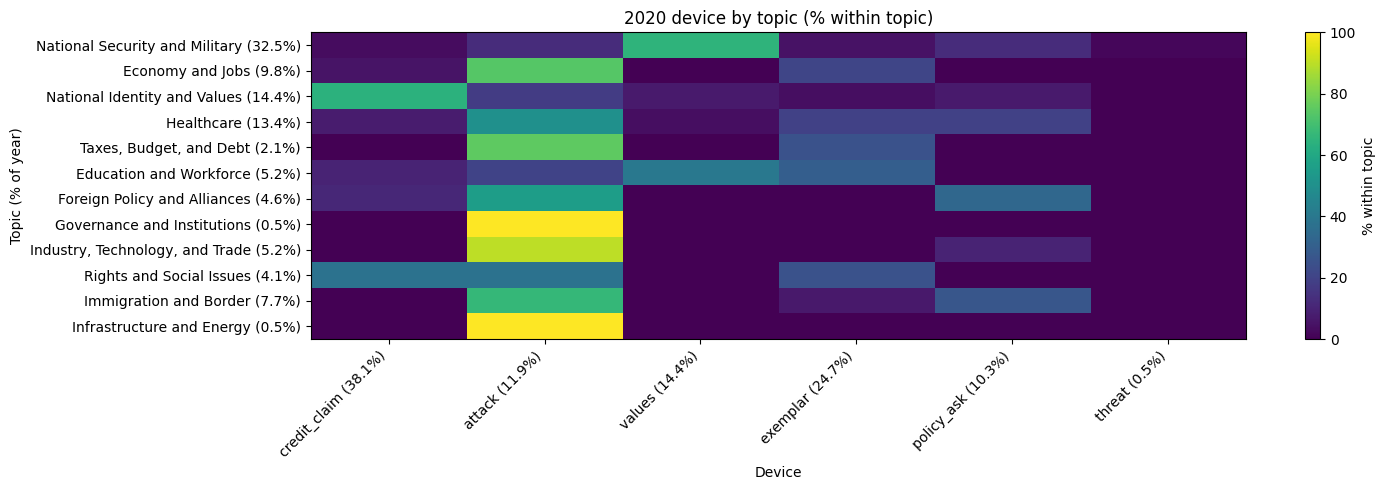

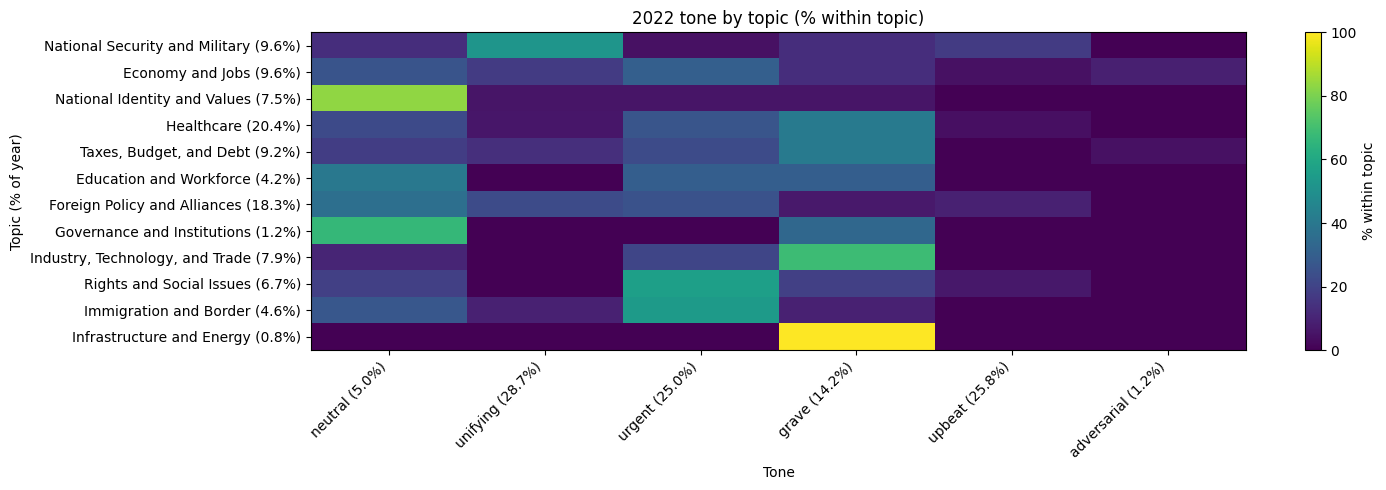

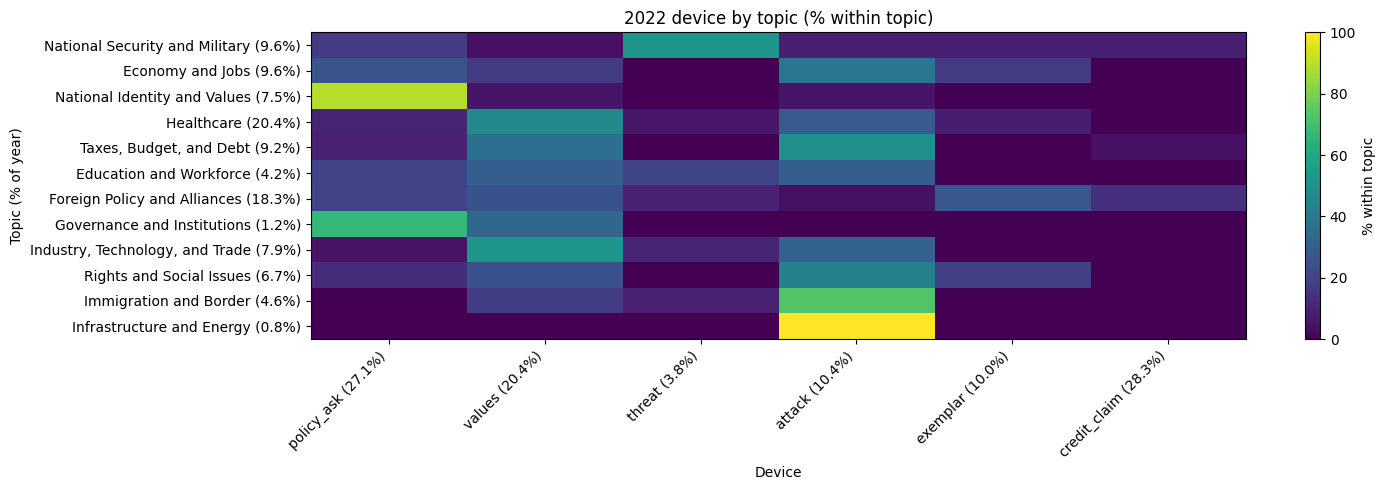

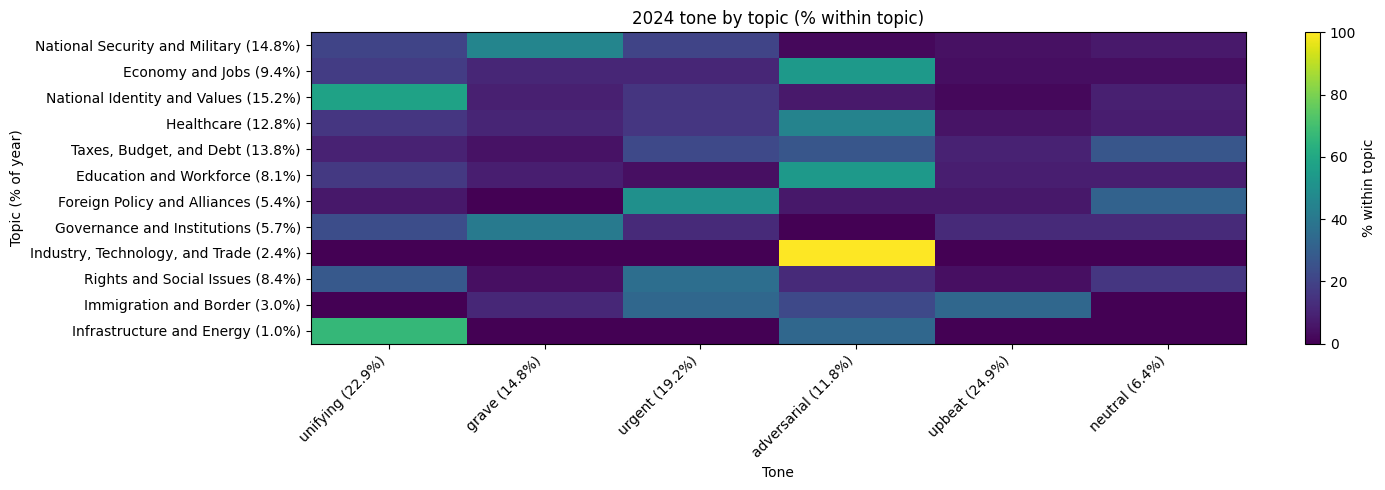

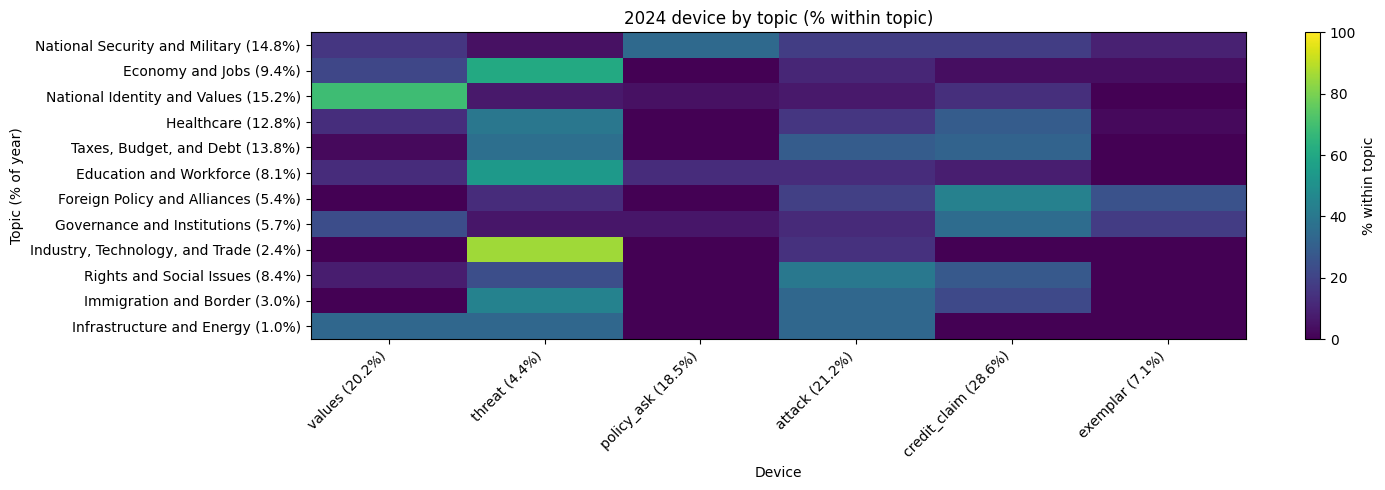

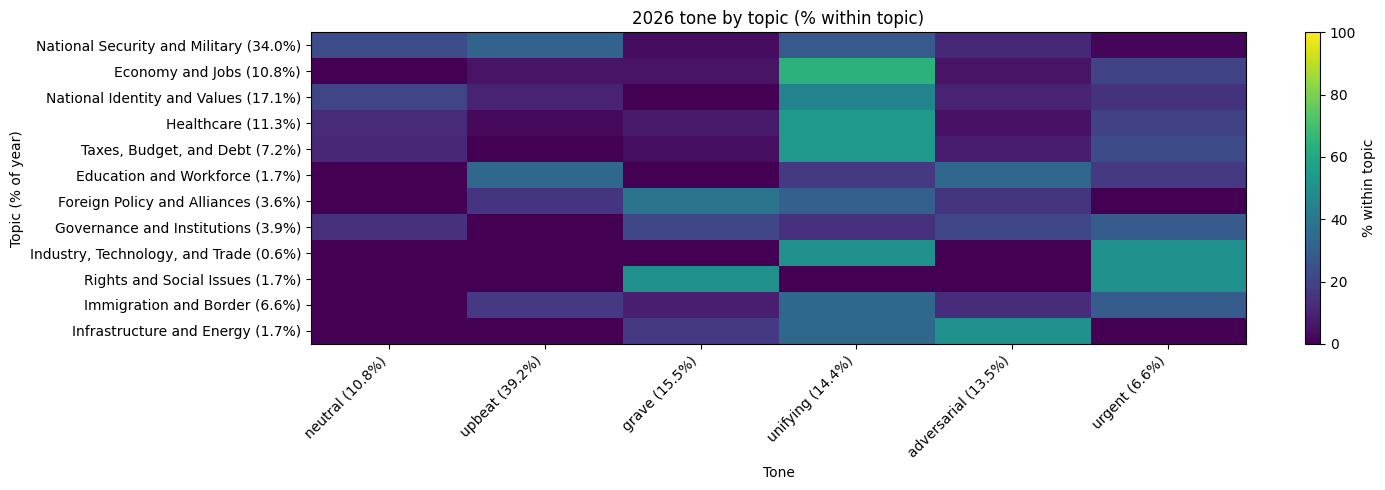

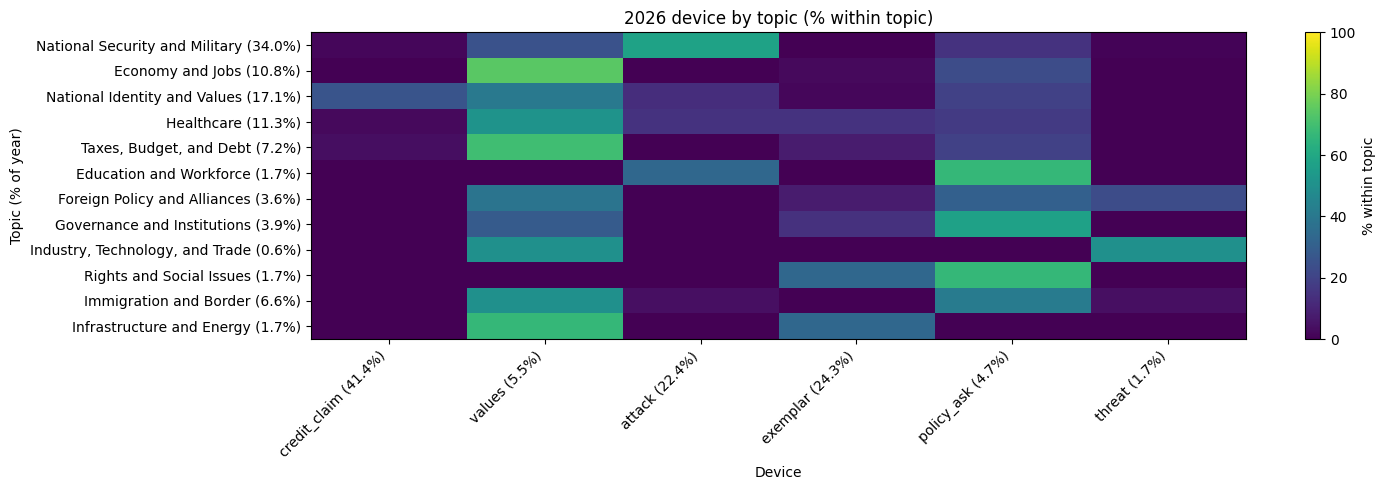

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

tones = (
    df2['tone'].dropna()
      .unique()
      .tolist()
)

devices = (
        df2['device'].dropna()
            .unique()
            .tolist()
)

topic_label_order = (
    df2["topic_label"]
      .value_counts()
      .index
      .tolist()
)
topic_label_order.sort()

macro_topic_order = (
    df2["macro_topic"]
      .value_counts()
      .index
    .tolist()
)
macro_topic_order

def topic_heatmap(data, year: int, topic="macro_topic", subgroup="device"):
    if subgroup not in {"tone", "device"}:
        raise ValueError("subgroup must be 'tone' or 'device'")
    elif subgroup == "tone":
        items = tones
    else:
        items = devices
    if topic not in {"macro_topic", "topic_label"}:
        raise ValueError("topic must be 'macro_topic' or 'topic_label'")
    elif topic == "macro_topic":
        topic_order = macro_topic_order
    else:
        topic_order = topic_label_order
    sub = data[(data["year"] == year) & data[subgroup].notna()].copy()
    counts = (
        sub.groupby([topic, subgroup])
           .size()
           .unstack(fill_value=0)
           .reindex(index=topic_order, columns=items, fill_value=0)
    )

    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = (counts.div(totals, axis=0) * 100.0).fillna(0.0)

    # y labels show topic share within the year (% of chunks in that year)
    topic_share = (sub[topic].value_counts(normalize=True) * 100).reindex(topic_order).fillna(0.0)
    yticklabels = [f"{t} ({topic_share[t]:.1f}%)" for t in topic_order]

    subgroup_share = (sub[subgroup].value_counts(normalize=True) * 100).reindex(getattr(sub, subgroup).unique()).fillna(0.0)
    xticklabels = [f"{t} ({subgroup_share[t]:.1f}%)" for t in getattr(sub, subgroup).unique()]

    fig, ax = plt.subplots(figsize=(15, max(5, 0.35 * len(topic_order))))
    im = ax.imshow(pct.values, aspect="auto", vmin=0, vmax=100)

    ax.set_title(f"{year} {subgroup} by topic (% within topic)")
    ax.set_xlabel(subgroup.title())
    ax.set_ylabel("Topic (% of year)")
    ax.set_xticks(range(len(items)))
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")
    ax.set_yticks(range(len(topic_order)))
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("% within topic")
    plt.tight_layout()
    plt.show()

for y in sorted(df2["year"].unique()):
    topic_heatmap(df2, y, subgroup="tone")
    topic_heatmap(df2, y, subgroup="device")


In [11]:
pd.options.display.max_rows = 200
#sub = data[(data["year"] == year) & data["device"].notna()].copy()
df2.groupby(by=["macro_topic","year"])["device"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=devices, fill_value=0).add_suffix("_device").merge(
    df2.groupby(by=["macro_topic","year"])["tone"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=tones, fill_value=0).add_suffix("_tone"),
    left_index=True,
    right_index=True
)

values_device  credit_claim_device  \
macro_topic                     year                                       
Economy and Jobs                2010       0.384615             0.307692   
                                2012       0.255814             0.162791   
                                2014       0.344828             0.172414   
                                2016       0.633333             0.133333   
                                2018       0.090909             0.272727   
                                2020       0.052632             0.736842   
                                2022       0.260870             0.173913   
                                2024       0.214286             0.607143   
                                2026       0.000000             0.743590   
Education and Workforce         2010       0.375000             0.062500   
                                2012       0.272727             0.242424   
                                2014       0.269231             0.153846   
                                2016       0.181818             0.272727   
                                2018       0.000000             0.333333   
                                2020       0.100000             0.200000   
                                2022       0.200000             0.300000   
                                2024       0.125000             0.541667   
                                2026       0.000000             0.000000   
Foreign Policy and Alliances    2010       0.375000             0.125000   
                                2012       0.333333             0.444444   
                                2014       0.285714             0.285714   
                                2016       0.250000             0.312500   
                                2018       0.111111             0.111111   
                                2020       0.111111             0.555556   
                                2022       0.204545             0.250000   
                                2024       0.000000             0.125000   
                                2026       0.000000             0.384615   
Governance and Institutions     2010       0.827586             0.034483   
                                2012       0.666667             0.000000   
                                2014       0.500000             0.000000   
                                2016       1.000000             0.000000   
                                2020       0.000000             1.000000   
                                2022       0.666667             0.333333   
                                2024       0.235294             0.058824   
                                2026       0.000000             0.285714   
Healthcare                      2010       0.100000             0.400000   
                                2012       0.000000             0.666667   
                                2014       0.238095             0.333333   
                                2016       0.400000             0.400000   
                                2018       0.000000             0.600000   
                                2020       0.076923             0.500000   
                                2022       0.102041             0.469388   
                                2024       0.131579             0.394737   
                                2026       0.024390             0.512195   
Immigration and Border          2012       0.000000             0.500000   
                                2018       0.100000             0.000000   
                                2020       0.000000             0.666667   
                                2022       0.000000             0.181818   
                                2024       0.000000             0.444444   
                                2026       0.000000             0.500000   
Industry, Technology, and Trade 2010       0.000000             0.142857   
          

In [12]:
df2.groupby(by="year")["tone"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=tones, fill_value=0)

tone,unifying,grave,urgent,upbeat,neutral,adversarial
year,,,,,,
2010,0.311321,0.169811,0.198113,0.179245,0.094340,0.047170
2012,0.293839,0.080569,0.265403,0.222749,0.099526,0.037915
2014,0.358382,0.075145,0.213873,0.265896,0.075145,0.011561
2016,0.431818,0.136364,0.181818,0.153409,0.062500,0.034091
2018,0.358491,0.132075,0.213836,0.276730,0.012579,0.006289
2020,0.247423,0.108247,0.103093,0.422680,0.072165,0.046392
2022,0.287500,0.141667,0.250000,0.258333,0.050000,0.012500
2024,0.228956,0.148148,0.191919,0.249158,0.063973,0.117845
2026,0.143646,0.154696,0.066298,0.392265,0.107735,0.135359


In [13]:
df2.groupby(by="year")["macro_topic"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=macro_topic_order, fill_value=0)

macro_topic,National Security and Military,Economy and Jobs,National Identity and Values,Healthcare,"Taxes, Budget, and Debt",Education and Workforce,Foreign Policy and Alliances,Governance and Institutions,"Industry, Technology, and Trade",Rights and Social Issues,Immigration and Border,Infrastructure and Energy
year,,,,,,,,,,,,
2010,0.051887,0.183962,0.122642,0.094340,0.198113,0.075472,0.037736,0.136792,0.033019,0.023585,0.000000,0.042453
2012,0.085308,0.203791,0.061611,0.014218,0.161137,0.156398,0.042654,0.028436,0.118483,0.014218,0.009479,0.104265
2014,0.150289,0.167630,0.069364,0.121387,0.127168,0.150289,0.080925,0.011561,0.034682,0.028902,0.000000,0.057803
2016,0.102273,0.170455,0.164773,0.085227,0.056818,0.062500,0.090909,0.142045,0.039773,0.028409,0.000000,0.056818
2018,0.371069,0.138365,0.201258,0.031447,0.062893,0.018868,0.056604,0.000000,0.025157,0.025157,0.062893,0.006289
2020,0.324742,0.097938,0.144330,0.134021,0.020619,0.051546,0.046392,0.005155,0.051546,0.041237,0.077320,0.005155
2022,0.095041,0.095041,0.074380,0.210744,0.090909,0.041322,0.181818,0.012397,0.078512,0.066116,0.045455,0.008264
2024,0.151007,0.093960,0.151007,0.127517,0.137584,0.080537,0.053691,0.057047,0.023490,0.083893,0.030201,0.010067
2026,0.339779,0.107735,0.171271,0.113260,0.071823,0.016575,0.035912,0.038674,0.005525,0.016575,0.066298,0.016575


In [14]:
df2.groupby(by="year")["device"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=devices, fill_value=0)

device,values,credit_claim,exemplar,policy_ask,attack,threat
year,,,,,,
2010,0.382075,0.245283,0.047170,0.207547,0.089623,0.028302
2012,0.246445,0.255924,0.047393,0.303318,0.127962,0.018957
2014,0.265896,0.202312,0.138728,0.346821,0.028902,0.017341
2016,0.505682,0.159091,0.034091,0.142045,0.090909,0.068182
2018,0.220126,0.194969,0.283019,0.182390,0.062893,0.056604
2020,0.144330,0.381443,0.247423,0.103093,0.118557,0.005155
2022,0.204167,0.283333,0.100000,0.270833,0.104167,0.037500
2024,0.202020,0.286195,0.070707,0.185185,0.212121,0.043771
2026,0.055249,0.414365,0.243094,0.046961,0.223757,0.016575


In [15]:
df2.head()

,year,chunk_id,chunk_index,uses_guest_example,guest_count,topic_id,tone,device,target,confidence,evidence,model,n_clauses,device_mix,tone_mix,error,topic_label,macro_topic,subtopic,macro_confidence
0,2010,2010_0000,0,False,0,6,unifying,values,the_public,high,{'device': 'Our Constitution declares that fro...,mistral:latest,1,{'values': 1},{'unifying': 1},NaN,Military Service: Ceremonial Events,National Security and Military,Military Ceremonies,high
1,2010,2010_0001,1,False,0,22,grave,values,the_public,high,{'device': 'assume that our progress was inevi...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Progress,National Identity and Values,American spirit,high
2,2010,2010_0002,2,False,0,22,grave,values,the_public,high,{'device': 'These were the times that tested t...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Progress,National Identity and Values,American spirit,high
3,2010,2010_0003,3,False,0,22,unifying,values,the_public,high,{'device': 'These were the times that tested t...,mistral:latest,1,{'values': 1},{'unifying': 1},NaN,National Progress,National Identity and Values,American spirit,high
4,2010,2010_0004,4,False,0,7,urgent,values,the_public,high,"{'device': 'we are tested. And again, we must ...",mistral:latest,1,{'values': 1},{'urgent': 1},NaN,Economic Inequality,Economy and Jobs,Economic Inequality,high


In [16]:
df2.groupby(by=['year','topic_label']).count()[['chunk_index']].pivot_table(index='topic_label', columns='year', values='chunk_index', fill_value=0)

year,2010,2012,2014,2016,2018,2020,2022,2024,2026
topic_label,,,,,,,,,
Border Security,0.0,2.0,0.0,0.0,10.0,15.0,11.0,9.0,24.0
Clean Energy,9.0,22.0,10.0,10.0,1.0,1.0,2.0,3.0,6.0
Counterterrorism,7.0,10.0,9.0,15.0,9.0,7.0,1.0,20.0,5.0
Economic Inequality,12.0,5.0,8.0,14.0,7.0,14.0,12.0,17.0,24.0
Financial Market Regulation,15.0,24.0,1.0,2.0,0.0,0.0,1.0,6.0,12.0
Fiscal Responsibility,32.0,18.0,13.0,4.0,2.0,0.0,8.0,15.0,13.0
Fundamental Rights,5.0,3.0,5.0,5.0,4.0,8.0,16.0,25.0,6.0
Global Security,8.0,9.0,13.0,16.0,9.0,9.0,9.0,6.0,11.0
Government Functionality,29.0,6.0,2.0,25.0,0.0,1.0,3.0,17.0,14.0
